# Step Timeline — Ground Type Classification
Single-bar timeline where each step is a colored segment along the time axis,
colored by predicted ground type. Misclassified steps are marked with a red outline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('step_timeline_full.csv')
df = df.sort_values('contact_time_sec').reset_index(drop=True)

print(f"Total steps: {len(df)}")
print(f"Duration: {df['contact_time_sec'].max():.1f}s")
print(f"Ground types: {df['ground_type'].unique()}")
print(f"Misclassified: {(df['ground_type'] != df['predicted_ground_type']).sum()}")

Total steps: 309
Duration: 192.6s
Ground types: ['Brick' 'Grass' 'Concrete']
Misclassified: 2


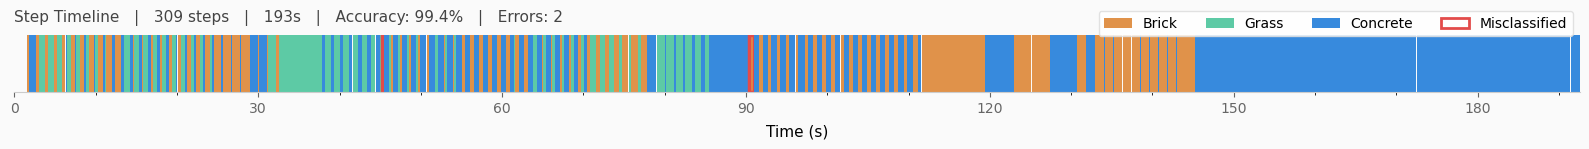

Saved to step_timeline_bar.png


In [2]:
# ── Colour palette ─────────────────────────────────────────────────────────────
COLORS = {
    'Brick':    '#E0924A',
    'Grass':    '#5DCAA5',
    'Concrete': '#378ADD',
}
ERROR_COLOR = '#E24B4A'

max_time = df['contact_time_sec'].max()

# ── Build figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 2.2))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

BAR_Y   = 0.0   # bottom of the bar
BAR_H   = 1.0   # height of the bar
MARGIN  = 0.01  # tiny gap between segments (fraction of total width)

for i, row in df.iterrows():
    t0 = row['contact_time_sec']
    # width = time until next step (or end of recording)
    if i < len(df) - 1:
        t1 = df.loc[i + 1, 'contact_time_sec']
    else:
        t1 = max_time

    width = max(t1 - t0 - MARGIN * max_time / len(df), 0.05)
    color = COLORS.get(row['ground_type'], '#AAAAAA')
    is_error = row['ground_type'] != row['predicted_ground_type']

    # Main coloured bar segment
    rect = mpatches.FancyBboxPatch(
        (t0, BAR_Y), width, BAR_H,
        boxstyle='square,pad=0',
        facecolor=color, edgecolor='none', linewidth=0
    )
    ax.add_patch(rect)

    # Red outline for errors
    if is_error:
        err_rect = mpatches.FancyBboxPatch(
            (t0, BAR_Y), width, BAR_H,
            boxstyle='square,pad=0',
            facecolor='none', edgecolor=ERROR_COLOR, linewidth=2.5
        )
        ax.add_patch(err_rect)

# ── Axes formatting ────────────────────────────────────────────────────────────
ax.set_xlim(0, max_time)
ax.set_ylim(BAR_Y, BAR_Y + BAR_H)
ax.set_yticks([])

ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.set_xlabel('Time (s)', fontsize=11, labelpad=6)

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(axis='x', colors='#666666', labelsize=10)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=c, label=label)
    for label, c in COLORS.items()
]
legend_handles.append(
    mpatches.Patch(facecolor='none', edgecolor=ERROR_COLOR,
                   linewidth=2, label='Misclassified')
)
ax.legend(
    handles=legend_handles,
    loc='upper right', fontsize=10,
    framealpha=0.85, edgecolor='#DDDDDD',
    ncol=4, bbox_to_anchor=(1, 1.55)
)

# ── Stats annotation ───────────────────────────────────────────────────────────
n_err = (df['ground_type'] != df['predicted_ground_type']).sum()
acc   = (1 - n_err / len(df)) * 100
ax.set_title(
    f"Step Timeline   |   {len(df)} steps   |   {max_time:.0f}s   |   Accuracy: {acc:.1f}%   |   Errors: {n_err}",
    fontsize=11, loc='left', pad=10, color='#444444'
)

plt.tight_layout()
plt.savefig('step_timeline_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to step_timeline_bar.png")

/var/folders/5_/nwk_4h3945ncxf6z1z8yzn040000gn/T/ipykernel_22456/1256587079.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


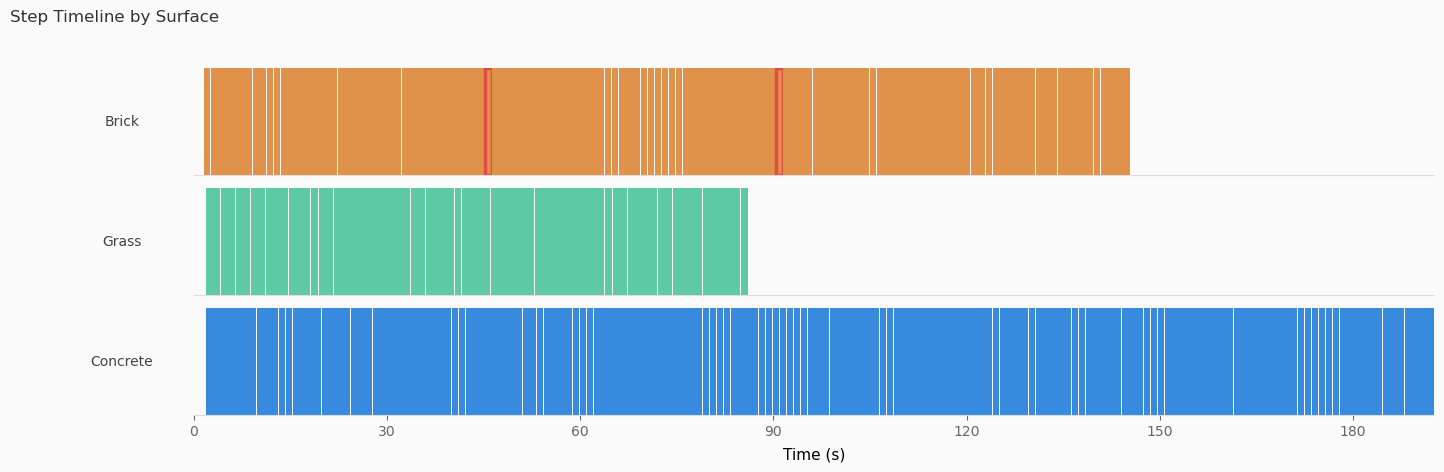

Saved to step_timeline_by_surface.png


In [3]:
# ── Optional: separate row per surface (stacked view) ─────────────────────────
surfaces = ['Brick', 'Grass', 'Concrete']

fig, axes = plt.subplots(len(surfaces), 1, figsize=(16, 4.5),
                          gridspec_kw={'hspace': 0.12})
fig.patch.set_facecolor('#FAFAFA')

for ax, surface in zip(axes, surfaces):
    ax.set_facecolor('#FAFAFA')
    sub = df[df['ground_type'] == surface].reset_index(drop=True)

    for i, row in sub.iterrows():
        t0 = row['contact_time_sec']
        if i < len(sub) - 1:
            t1 = sub.loc[i + 1, 'contact_time_sec']
        else:
            t1 = t0 + 1.2  # last step: fixed width

        width = max(t1 - t0 - 0.05, 0.1)
        is_error = row['ground_type'] != row['predicted_ground_type']
        color = COLORS[surface]

        rect = mpatches.FancyBboxPatch(
            (t0, 0), width, 1,
            boxstyle='square,pad=0',
            facecolor=color, edgecolor='none'
        )
        ax.add_patch(rect)

        if is_error:
            err = mpatches.FancyBboxPatch(
                (t0, 0), width, 1,
                boxstyle='square,pad=0',
                facecolor='none', edgecolor=ERROR_COLOR, linewidth=2.5
            )
            ax.add_patch(err)

    ax.set_xlim(0, max_time)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(surface, fontsize=10, rotation=0,
                  labelpad=52, va='center', color='#444444')

    for spine in ['top', 'left', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#DDDDDD')

    if ax != axes[-1]:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
    else:
        ax.set_xlabel('Time (s)', fontsize=11, labelpad=6)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
        ax.tick_params(axis='x', colors='#666666', labelsize=10)

fig.suptitle('Step Timeline by Surface', fontsize=12,
             x=0.01, ha='left', color='#333333', y=1.01)

plt.tight_layout()
plt.savefig('step_timeline_by_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to step_timeline_by_surface.png")